In [1]:
import math
import numpy as np

# --- 1. Filter Specifications ---
f0 = 6.9e9  # Center frequency: 4 GHz
w0 = 2 * math.pi * f0
FBW = 400e6 / f0  # Fractional bandwidth: 10%
Z0 = 50.0  # System impedance: 50 Ohms
Y0 = 1.0 / Z0  # System admittance
Zr = 50.0  # Resonator characteristic impedance: 50 Ohms
Yr = 1.0 / Zr  # Resonator characteristic admittance

# --- 2. Butterworth N=2 Low-Pass Prototype Coefficients ---
g0 = 1.0
g1 = 1.41421356  # 2 * sin(pi/4)
g2 = 1.41421356  # 2 * sin(3pi/4)
g3 = 1.0

# # Chebyshev 0.1 dB
# g0 = 1.0
# g1 = 0.8431
# g2 = 0.6220
# g3 = 1.3554

# # Chebyshev 0.01 dB
# g0 = 1.0
# g1 = 0.4489
# g2 = 0.4078
# g3 = 1.1008

# # Gaussian
# g0 = 1.0
# g1 = 1.5774
# g2 = 0.4226
# g3 = 1.0

# --- 3. Resonator Susceptance Slope Parameter ---
b = (math.pi / 4.0) * Yr

# --- 4. Admittance Inverters (J) ---
J01 = math.sqrt((Y0 * b * FBW) / (g0 * g1))
J12 = FBW * b / math.sqrt(g1 * g2)
J23 = math.sqrt((Y0 * b * FBW) / (g2 * g3))

# # --- 5. Component Realization ---
# # Series Capacitors (Cs1 and Cs2)
B_c1 = J01 / (1.0 - (J01 / Y0) ** 2)
B_c2 = J23 / (1.0 - (J23 / Y0) ** 2)

Cs1 = B_c1 / w0
Cs2 = B_c2 / w0

# CORRECTED: Shunt Inductor (Lp)
# The lambda/4 lines transform the shunt Lp into a series Leq at the open ends
Lp = (J12 * Zr**2) / w0

lineShunt = np.arctan(Zr**2 * J12 / Zr)

# --- 6. Resonator Length Correction ---
# CORRECTED: Both the series C and shunt L require shortening the physical line.
# Susceptances are additive for the length compensation.
# Susceptances are additive for the length compensation
numerator1 = B_c1 + J12
x1 = numerator1 / Yr

theta1_rad = (math.pi / 2.0) - math.atan(x1)
theta1_deg = math.degrees(theta1_rad)

# Symmetrical filter (g1=g2), so theta2 will equal theta1
# Calculated explicitly here for completeness if g-values change
numerator2 = B_c2 + J12
x2 = numerator2 / Yr

theta2_rad = (math.pi / 2.0) - math.atan(x2)
theta2_deg = math.degrees(theta2_rad)

thetaShunt_deg = math.degrees(lineShunt)

print("--- Corrected Physical Component Values ---")
print(f"Series Capacitor (C1) : {Cs1 * 1e12:.3f} pF")
print(f"Series Capacitor (C2) : {Cs2 * 1e12:.3f} pF")
print(f"Shunt Inductor (Lp)   : {Lp * 1e9:.3f} nH\n")

print("--- Resonator Electrical Lengths ---")
print("Uncorrected length : 90.00 degrees (lambda/4)")
print(f"Corrected Theta 1  : {theta1_deg:.2f} degrees")
print(f"Corrected Theta 2  : {theta2_deg:.2f} degrees")
print(f"Shunt Line Theta   : {thetaShunt_deg:.2f} degrees\n")


--- Corrected Physical Component Values ---
Series Capacitor (C1) : 0.086 pF
Series Capacitor (C2) : 0.086 pF
Shunt Inductor (Lp)   : 0.037 nH

--- Resonator Electrical Lengths ---
Uncorrected length : 90.00 degrees (lambda/4)
Corrected Theta 1  : 77.72 degrees
Corrected Theta 2  : 77.72 degrees
Shunt Line Theta   : 1.84 degrees



In [2]:
import skrf as rf
import numpy as np

rf.stylely()

from skrf_cqed.elements.tline_wrapper import DefinedBetaZ0

freq = rf.Frequency(2, 25, 2001, "ghz")
epsilon_r = 5.567
vph = rf.constants.c / np.sqrt(epsilon_r)

media = DefinedBetaZ0(frequency=freq, vph=vph, z0=50)

In [3]:
Lp

3.7130160805140463e-11

In [4]:
import matplotlib.pyplot as plt

In [5]:
line1 = media.line_electrical_length(theta1_deg, f0, name="L1", unit="deg")
line2 = media.line_electrical_length(theta2_deg, f0, name="L2", unit="deg")
shunt_line = media.line_electrical_length(thetaShunt_deg, f0, name="Lshunt", unit="deg")

cap1 = media.capacitor(Cs1, name="C1")
cap2 = media.capacitor(Cs2, name="C2")

ind = media.inductor(Lp, name="Ls")

gnd = rf.circuit.Circuit.Ground(freq, name="GND")
portI = rf.circuit.Circuit.Port(freq, name="port0")
portO = rf.circuit.Circuit.Port(freq, name="port1")

cnx = [
    [(cap1, 0), (portI, 0)],
    [(line1, 0), (cap1, 1)],
    [(line1, 1), (ind, 0), (line2, 0)],
    [(ind, 1), (gnd, 0)],
    [(line2, 1), (cap2, 0)],
    [(cap2, 1), (portO, 0)],
]

circ = rf.circuit.Circuit(
    cnx,
    name="filter",
)
network = circ.network


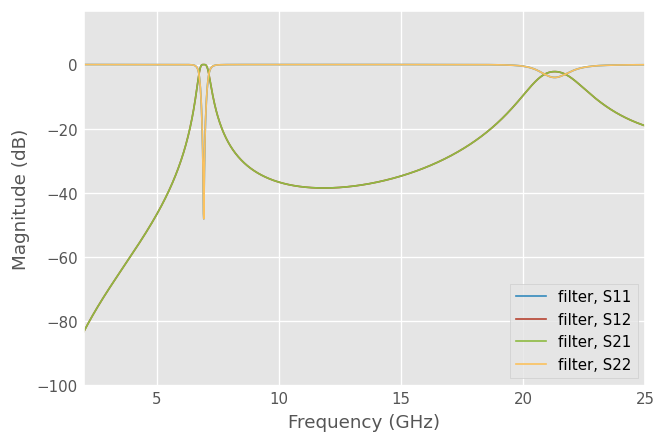

In [8]:

network.plot_s_db()

# plt.xlim([6.6e9, 7.4e9])

# plt.xlim(f0 - 1.5*FBW * f0 / 2, f0 + 1.5*FBW * f0 / 2)
# plt.ylim([-3, 0.1])

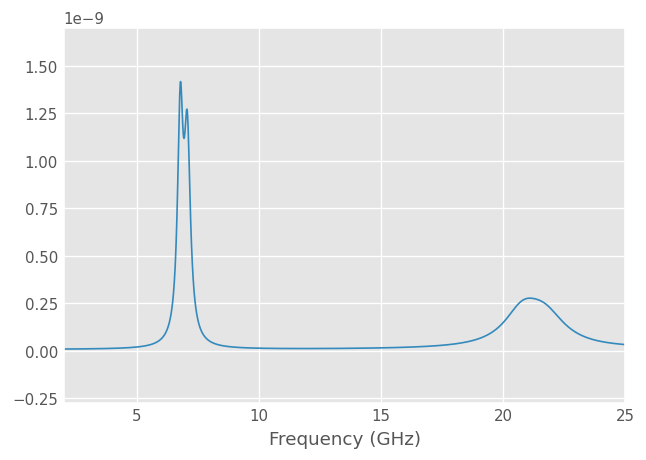

In [7]:
gd = abs(network.s21.group_delay)
network.plot(gd)
# plt.xlim([6.6e9, 7.4e9])